In [1]:
import pandas as pd
import plotly.graph_objects as go
import os

BASE     = r"C:\PROGETTO_L2(BioTecnologie)analisi"
ALMALAUREA = os.path.join(BASE, "ALMALAUREA_occupazione")

# ── MIUR ──────────────────────────────────────────────────────────────────────
df_miur = pd.read_csv(
    os.path.join(BASE, "MURiscrittixcorsodistudi.csv"),
    sep=None, engine="python", encoding="latin-1"
)

# Filtra L-2 e anni 2021-2024
anni = ["2021/2022", "2022/2023", "2023/2024", "2024/2025"]
df_l2_corsi = df_miur[
    (df_miur["ClasseNUMERO"] == "L-2") &
    (df_miur["AnnoA"].isin(anni))
].copy()

# Unifica nomi
df_l2_corsi["CorsoNOME"] = df_l2_corsi["CorsoNOME"].replace({
    "Biotecnologia":  "Biotecnologie",
    "BIOTECNOLOGIE":  "Biotecnologie",
})

# Mappa ateneo → regione → macro area
ATENEO_REGIONE = {
    "Torino": "Piemonte", "Piemonte Orientale": "Piemonte",
    "Genova": "Liguria",
    "Milano": "Lombardia", "Milano Bicocca": "Lombardia",
    "Milano San Raffaele": "Lombardia", "Insubria": "Lombardia",
    "Brescia": "Lombardia", "Pavia": "Lombardia",
    "Trento": "Trentino",
    "Verona": "Veneto", "Padova": "Veneto",
    "Trieste": "Friuli", "Udine": "Friuli",
    "Bologna": "Emilia", "Ferrara": "Emilia",
    "Modena e Reggio Emilia": "Emilia", "Parma": "Emilia",
    "Firenze": "Toscana", "Siena": "Toscana", "Pisa": "Toscana",
    "Perugia": "Umbria",
    "Camerino": "Marche", "Urbino": "Marche",
    "Roma La Sapienza": "Lazio", "Roma Tor Vergata": "Lazio",
    "Tuscia": "Lazio",
    "L'Aquila": "Abruzzo", "Teramo": "Abruzzo",
    "Napoli Federico II": "Campania", "Napoli Vanvitelli": "Campania",
    "Sannio": "Campania",
    "Bari": "Puglia", "Salento": "Puglia", "Foggia": "Puglia",
    "Basilicata": "Basilicata",
    "Catanzaro": "Calabria", "Calabria": "Calabria",
    "Palermo": "Sicilia", "Catania": "Sicilia", "Messina": "Sicilia",
    "Cagliari": "Sardegna", "Sassari": "Sardegna",
}

REGIONE_MACRO = {
    "Piemonte": "Nord", "Liguria": "Nord", "Lombardia": "Nord",
    "Trentino": "Nord", "Veneto": "Nord", "Friuli": "Nord",
    "Emilia": "Nord", "Toscana": "Centro", "Umbria": "Centro",
    "Marche": "Centro", "Lazio": "Centro", "Abruzzo": "Sud",
    "Campania": "Sud", "Puglia": "Sud", "Basilicata": "Sud",
    "Calabria": "Sud", "Sicilia": "Isole", "Sardegna": "Isole",
}

REGIONE_GEO = {
    "Piemonte": "Piemonte", "Liguria": "Liguria",
    "Lombardia": "Lombardia",
    "Trentino": "Trentino-Alto Adige/Südtirol",
    "Veneto": "Veneto", "Friuli": "Friuli-Venezia Giulia",
    "Emilia": "Emilia-Romagna", "Toscana": "Toscana",
    "Umbria": "Umbria", "Marche": "Marche", "Lazio": "Lazio",
    "Abruzzo": "Abruzzo", "Campania": "Campania", "Puglia": "Puglia",
    "Basilicata": "Basilicata", "Calabria": "Calabria",
    "Sicilia": "Sicilia", "Sardegna": "Sardegna",
}

COLORI = {
    "Nord": "#2563EB", "Centro": "#16A34A",
    "Sud": "#DC2626", "Isole": "#D97706",
}

GEOJSON_URL = (
    "https://raw.githubusercontent.com/openpolis/geojson-italy/"
    "master/geojson/limits_IT_regions.geojson"
)

df_l2_corsi["regione"]    = df_l2_corsi["AteneoNOME"].map(ATENEO_REGIONE)
df_l2_corsi["macro_area"] = df_l2_corsi["regione"].map(REGIONE_MACRO)
df_l2_corsi["reg_name"]   = df_l2_corsi["regione"].map(REGIONE_GEO)

print("✅ Dati caricati!")
print(f"Righe L-2: {len(df_l2_corsi)}")

✅ Dati caricati!
Righe L-2: 454


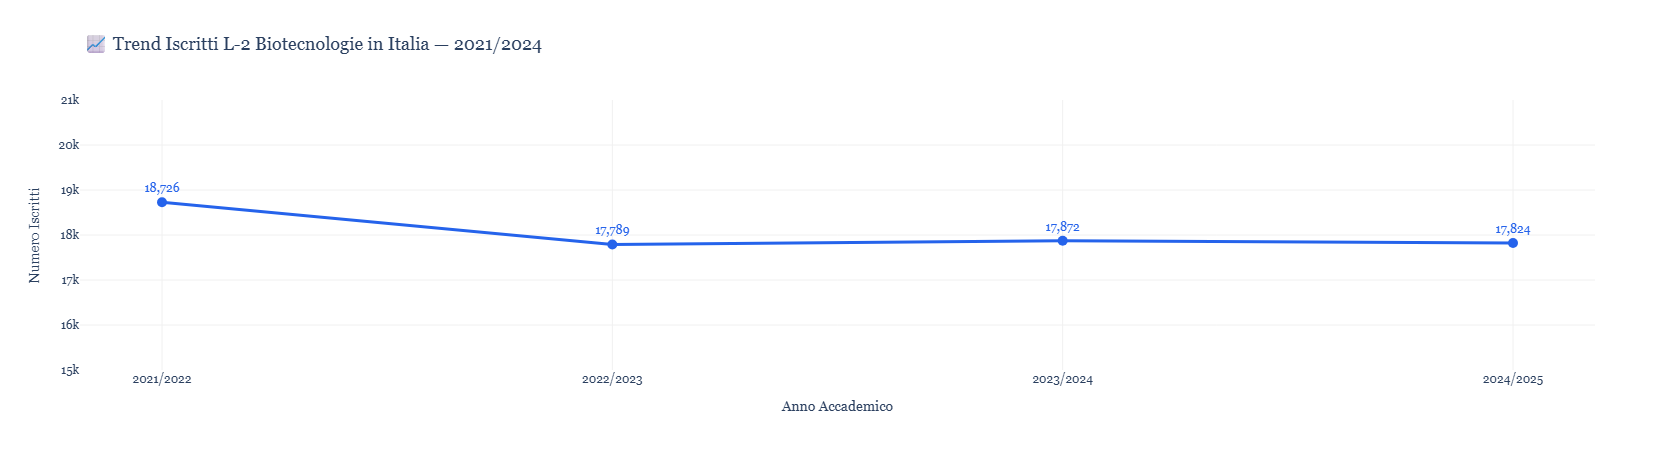

In [2]:
df_l2_tot = (
    df_l2_corsi.groupby("AnnoA")["Isc"]
    .sum()
    .reset_index()
    .rename(columns={"AnnoA": "anno", "Isc": "iscritti_totale"})
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_l2_tot["anno"],
    y=df_l2_tot["iscritti_totale"],
    mode="lines+markers+text",
    line=dict(color="#2563EB", width=3),
    marker=dict(size=10, color="#2563EB"),
    text=df_l2_tot["iscritti_totale"].apply(lambda x: f"{x:,.0f}"),
    textposition="top center",
    textfont=dict(size=12, color="#2563EB"),
    hovertemplate="<b>%{x}</b><br>Iscritti: %{y:,.0f}<extra></extra>",
))

fig.update_layout(
    title="📈 Trend Iscritti L-2 Biotecnologie in Italia — 2021/2024",
    xaxis_title="Anno Accademico",
    yaxis_title="Numero Iscritti",
    height=450,
    font_family="Georgia",
    title_font_size=18,
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#f0f0f0"),
    yaxis=dict(gridcolor="#f0f0f0", range=[15000, 21000]),
)

fig.show()

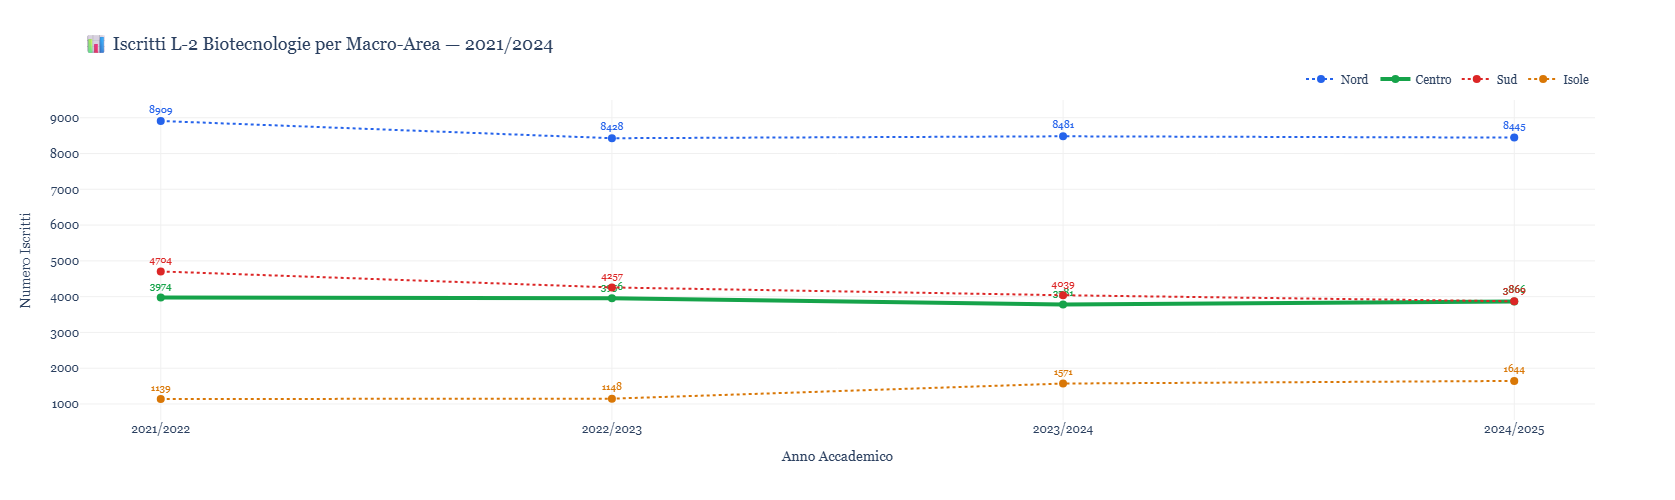

In [3]:
df_macro_anno = (
    df_l2_corsi.groupby(["AnnoA", "macro_area"])["Isc"]
    .sum()
    .reset_index()
)

fig = go.Figure()

for macro in ["Nord", "Centro", "Sud", "Isole"]:
    subset = df_macro_anno[df_macro_anno["macro_area"] == macro]
    spessore = 4 if macro == "Centro" else 2
    dash = "solid" if macro == "Centro" else "dot"

    fig.add_trace(go.Scatter(
        x=subset["AnnoA"],
        y=subset["Isc"],
        mode="lines+markers+text",
        name=macro,
        line=dict(color=COLORI[macro], width=spessore, dash=dash),
        marker=dict(size=8, color=COLORI[macro]),
        text=subset["Isc"].astype(str),
        textposition="top center",
        textfont=dict(size=10, color=COLORI[macro]),
        hovertemplate=f"<b>{macro}</b><br>Anno: %{{x}}<br>Iscritti: %{{y:,.0f}}<extra></extra>",
    ))

fig.update_layout(
    title="📊 Iscritti L-2 Biotecnologie per Macro-Area — 2021/2024",
    xaxis_title="Anno Accademico",
    yaxis_title="Numero Iscritti",
    height=500,
    font_family="Georgia",
    title_font_size=18,
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#f0f0f0"),
    yaxis=dict(gridcolor="#f0f0f0"),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
)

fig.show()

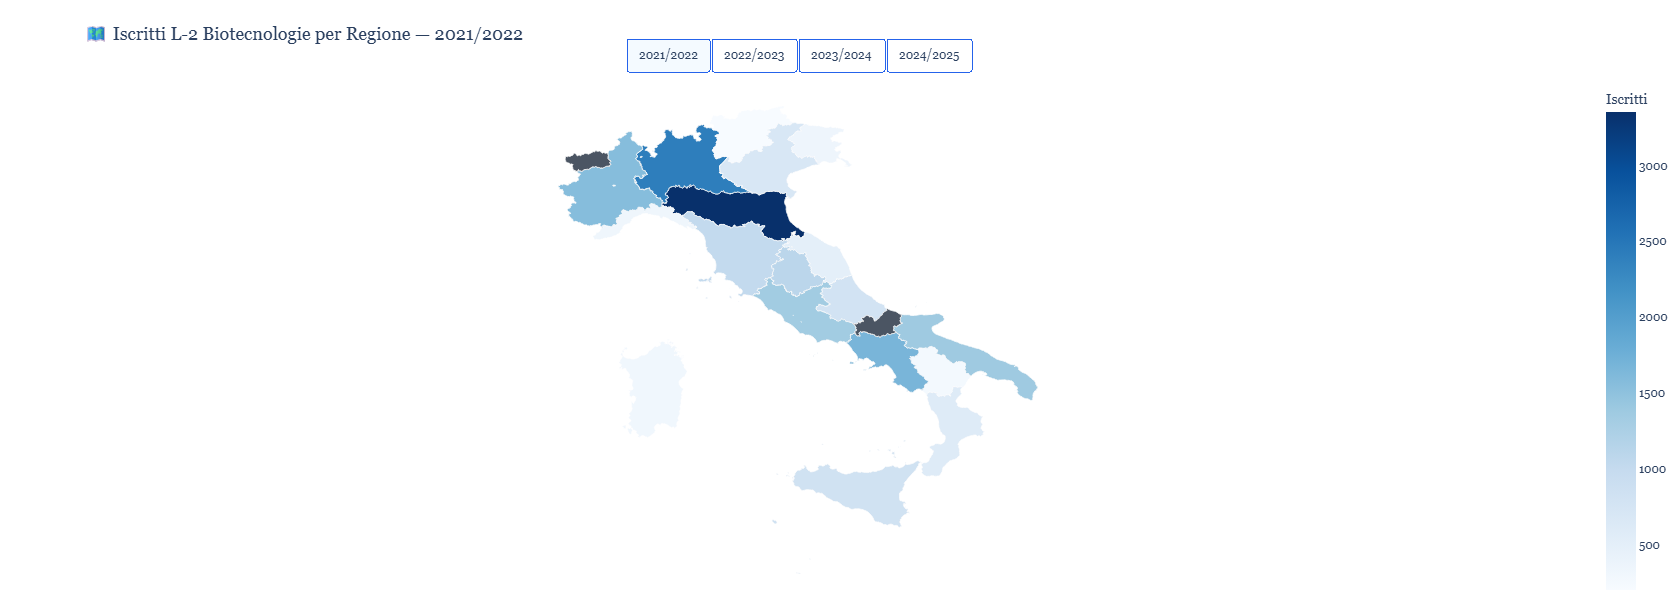

In [4]:
df_mappa_anni = (
    df_l2_corsi.groupby(["AnnoA", "regione", "macro_area", "reg_name"])["Isc"]
    .sum()
    .reset_index()
    .rename(columns={"Isc": "iscritti_totale"})
)

df_hover_anni = (
    df_l2_corsi.groupby(["AnnoA", "regione", "AteneoNOME", "CorsoNOME"])["Isc"]
    .sum()
    .reset_index()
)

def crea_hover_anno(regione, anno):
    subset = df_hover_anni[
        (df_hover_anni["regione"] == regione) &
        (df_hover_anni["AnnoA"] == anno)
    ].sort_values("Isc", ascending=False)
    totale = int(subset["Isc"].sum())
    testo = f"<b>{regione}</b><br>Anno: {anno} | Totale iscritti: <b>{totale:,}</b><br><br>"
    for _, row in subset.iterrows():
        testo += f"🎓 {row['AteneoNOME']}<br>"
        testo += f"&nbsp;&nbsp;{row['CorsoNOME']}: {int(row['Isc']):,} iscritti<br>"
    return testo

df_mappa_anni["hover_text"] = df_mappa_anni.apply(
    lambda r: crea_hover_anno(r["regione"], r["AnnoA"]), axis=1
)

anni_ordinati = ["2021/2022", "2022/2023", "2023/2024", "2024/2025"]
no_corso_nomi = ["Valle d'Aosta/Vallée d'Aoste", "Molise"]

z_min = df_mappa_anni["iscritti_totale"].min()
z_max = df_mappa_anni["iscritti_totale"].max()

fig = go.Figure()

for i, anno in enumerate(anni_ordinati):
    subset = df_mappa_anni[df_mappa_anni["AnnoA"] == anno]

    fig.add_trace(go.Choropleth(
        geojson=GEOJSON_URL,
        locations=subset["reg_name"],
        featureidkey="properties.reg_name",
        z=subset["iscritti_totale"],
        colorscale="Blues",
        zmin=z_min,
        zmax=z_max,
        colorbar=dict(title="Iscritti", x=1.0),
        marker_line_color="white",
        marker_line_width=1,
        text=subset["hover_text"],
        hovertemplate="%{text}<extra></extra>",
        name=anno,
        visible=(i == 0),
    ))

    fig.add_trace(go.Choropleth(
        geojson=GEOJSON_URL,
        locations=no_corso_nomi,
        featureidkey="properties.reg_name",
        z=[0, 0],
        colorscale=[[0, "#4B5563"], [1, "#4B5563"]],
        showscale=False,
        marker_line_color="white",
        marker_line_width=1,
        hovertemplate="<b>%{location}</b><br>Nessun corso L2 attivo<extra></extra>",
        name="Nessun corso",
        visible=(i == 0),
    ))

buttons = []
for i, anno in enumerate(anni_ordinati):
    visibilita = []
    for j in range(len(anni_ordinati)):
        visibilita.append(j == i)
        visibilita.append(j == i)
    buttons.append(dict(
        label=anno,
        method="update",
        args=[
            {"visible": visibilita},
            {"title": f"🗺️ Iscritti L-2 Biotecnologie per Regione — {anno}"}
        ]
    ))

fig.update_layout(
    title=f"🗺️ Iscritti L-2 Biotecnologie per Regione — {anni_ordinati[0]}",
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=0.5, xanchor="center",
        y=1.08, yanchor="top",
        buttons=buttons,
        bgcolor="white",
        bordercolor="#2563EB",
        borderwidth=1,
        font=dict(size=12),
    )],
    margin={"r": 0, "t": 80, "l": 0, "b": 0},
    height=600,
    font_family="Georgia",
    title_font_size=18,
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

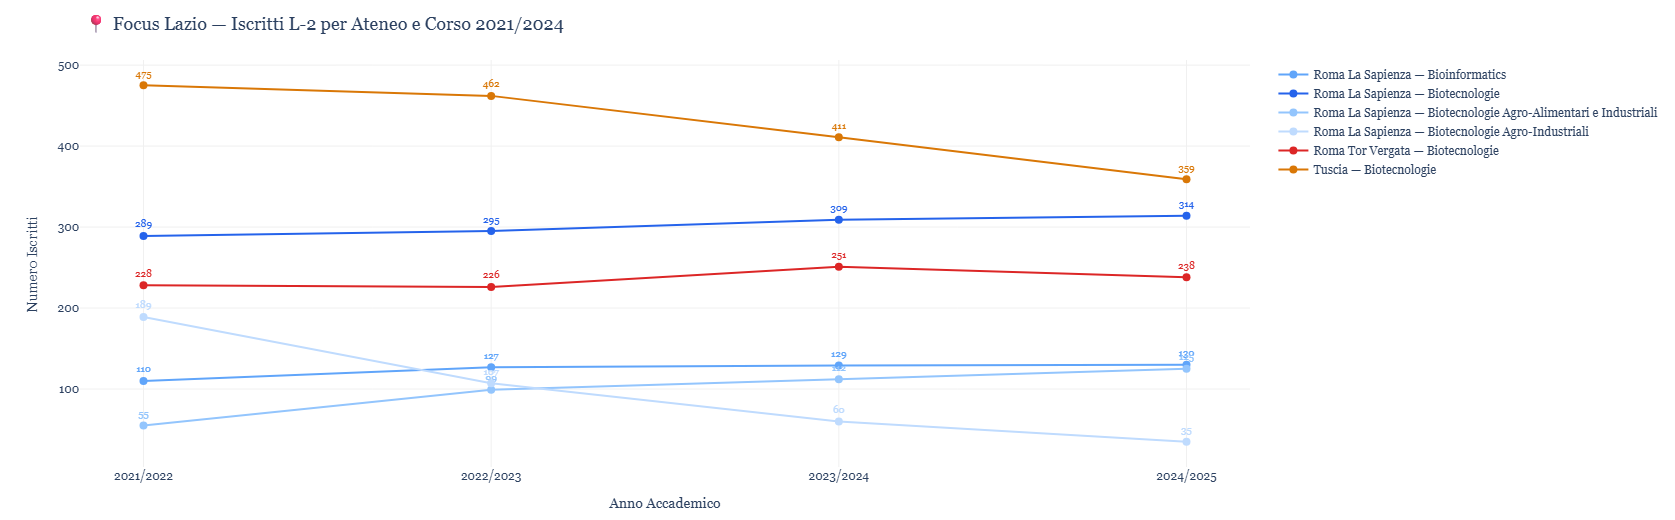

In [5]:
df_lazio = df_l2_corsi[df_l2_corsi["regione"] == "Lazio"].copy()

df_lazio_trend = (
    df_lazio.groupby(["AnnoA", "AteneoNOME", "CorsoNOME"])["Isc"]
    .sum()
    .reset_index()
)

df_lazio_trend["label"] = (
    df_lazio_trend["AteneoNOME"] + " — " + df_lazio_trend["CorsoNOME"]
)

COLORI_ATENEO = {
    "Roma La Sapienza — Biotecnologie":                               "#2563EB",
    "Roma La Sapienza — Bioinformatics":                              "#60A5FA",
    "Roma La Sapienza — Biotecnologie Agro-Alimentari e Industriali": "#93C5FD",
    "Roma La Sapienza — Biotecnologie Agro-Industriali":              "#BFDBFE",
    "Roma Tor Vergata — Biotecnologie":                               "#DC2626",
    "Tuscia — Biotecnologie":                                         "#D97706",
}

fig = go.Figure()

for label in df_lazio_trend["label"].unique():
    subset = df_lazio_trend[df_lazio_trend["label"] == label].sort_values("AnnoA")
    colore = COLORI_ATENEO.get(label, "#6B7280")

    fig.add_trace(go.Scatter(
        x=subset["AnnoA"],
        y=subset["Isc"],
        mode="lines+markers+text",
        name=label,
        line=dict(color=colore, width=2),
        marker=dict(size=8, color=colore),
        text=subset["Isc"].astype(str),
        textposition="top center",
        textfont=dict(size=10, color=colore),
        hovertemplate=f"<b>{label}</b><br>Anno: %{{x}}<br>Iscritti: %{{y}}<extra></extra>",
    ))

fig.update_layout(
    title="📍 Focus Lazio — Iscritti L-2 per Ateneo e Corso 2021/2024",
    xaxis_title="Anno Accademico",
    yaxis_title="Numero Iscritti",
    height=520,
    font_family="Georgia",
    title_font_size=18,
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#f0f0f0"),
    yaxis=dict(gridcolor="#f0f0f0"),
    legend=dict(orientation="v", x=1.02, y=1, xanchor="left"),
    margin=dict(r=350, t=60, b=40),
)

fig.show()